# Temporal Coverage of Regridded SW Pacific Profiles

In [7]:
# Imports
import numpy as np
import pandas as pd
import xarray as xr
import datetime
import time
import matplotlib.pyplot as plt

In [3]:
s3_path = "s3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_full.zarr"
ds_all_floats = xr.open_zarr(s3_path)

ds_all_floats

<xarray.Dataset> Size: 56MB
Dimensions:          (profile: 994, pres: 1001)
Coordinates:
    CYCLE_NUMBER     (profile) int64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    JULD             (profile) datetime64[ns] 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LATITUDE         (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LONGITUDE        (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    PLATFORM_NUMBER  (profile) <U7 28kB dask.array<chunksize=(994,), meta=np.ndarray>
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * profile          (profile) int64 8kB 0 1 2 3 4 5 ... 988 989 990 991 992 993
Data variables:
    ABS_SAL          (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    AOU              (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    CHLA             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    DOXY             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    O2_SATURATION    (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    POTENTIAL_TEMP   (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    TEMP             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp

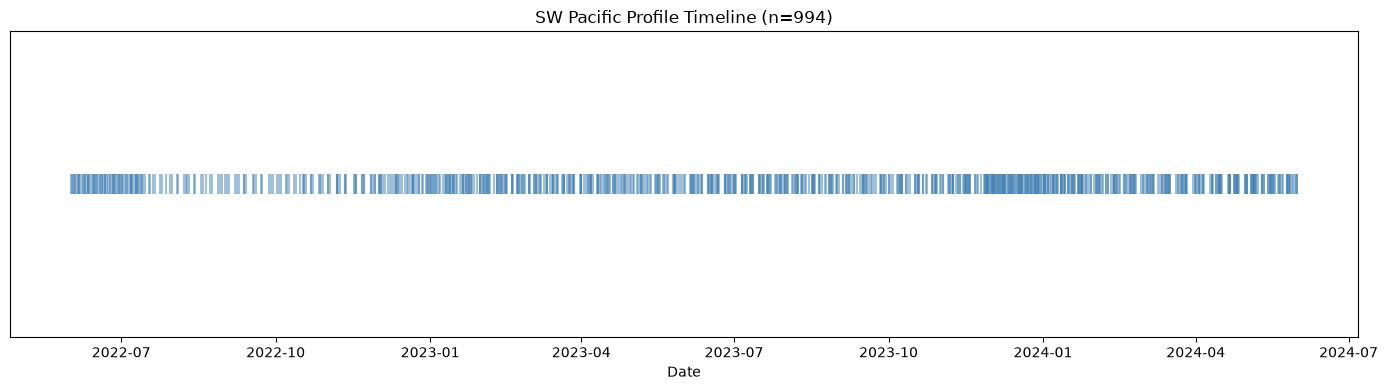

In [8]:
juld_all = pd.to_datetime(ds_all_floats["JULD"].values)

# Timeline scatter: one point per profile, by date
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(juld_all, np.zeros(len(juld_all)), marker="|", s=200, alpha=0.5, color="steelblue")
ax.set_yticks([])
ax.set_xlabel("Date")
ax.set_title(f"SW Pacific Profile Timeline (n={len(juld_all)})")
plt.tight_layout()
plt.show()

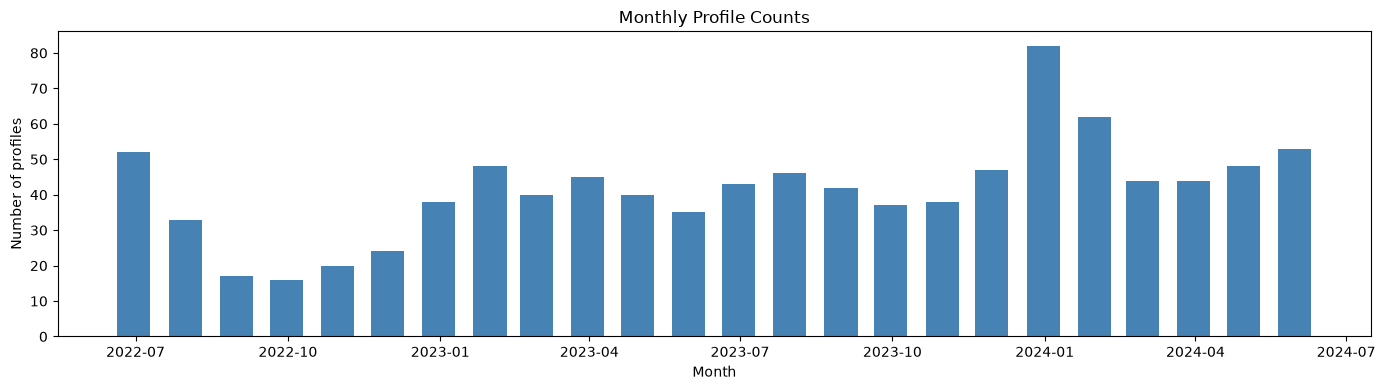

In [9]:
# Monthly profile counts — shows seasonal/temporal density, useful before
# building a day-of-year or monthly climatology
monthly_counts = pd.Series(1, index=juld_all).resample("ME").sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_counts.index, monthly_counts.values, width=20, color="steelblue")
ax.set_ylabel("Number of profiles")
ax.set_xlabel("Month")
ax.set_title("Monthly Profile Counts")
plt.tight_layout()
plt.show()

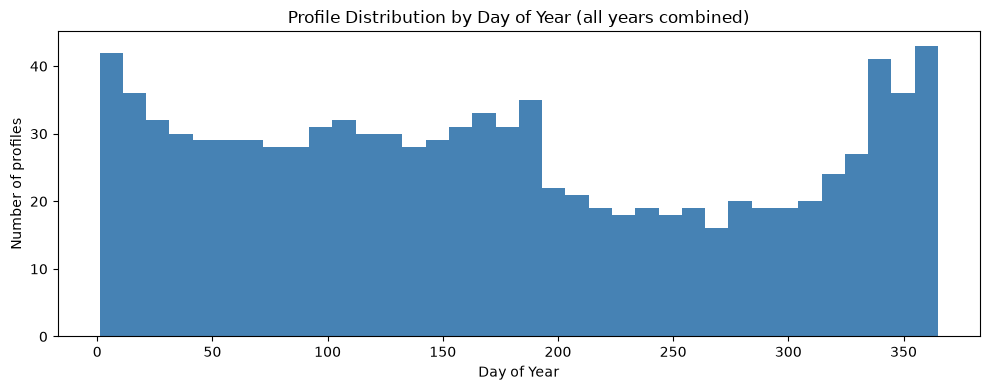

In [10]:
# Day-of-year distribution — relevant if building a day-of-year climatology
# (shows whether all seasons are represented, or some months are sparse)
doy_all = juld_all.dayofyear

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(doy_all, bins=36, color="steelblue")
ax.set_xlabel("Day of Year")
ax.set_ylabel("Number of profiles")
ax.set_title("Profile Distribution by Day of Year (all years combined)")
plt.tight_layout()
plt.show()

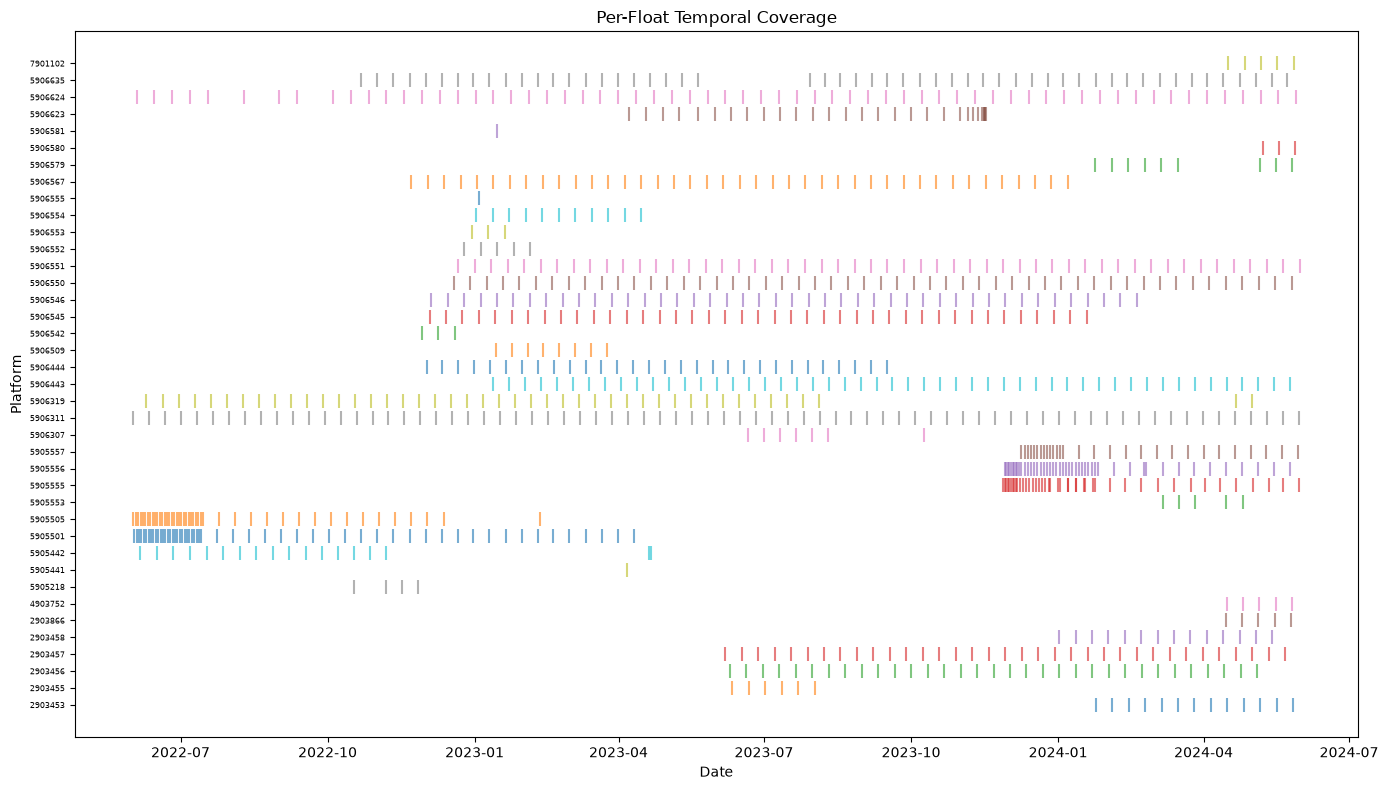

In [11]:
# Per-float coverage over time to see which floats cover which periods
platforms_all = ds_all_floats["PLATFORM_NUMBER"].values
unique_platforms = np.unique(platforms_all)

fig, ax = plt.subplots(figsize=(14, 8))
for i, p in enumerate(unique_platforms):
    mask = platforms_all == p
    ax.scatter(juld_all[mask], [i] * mask.sum(), marker="|", s=100, alpha=0.6)

ax.set_yticks(range(len(unique_platforms)))
ax.set_yticklabels(unique_platforms, fontsize=6)
ax.set_xlabel("Date")
ax.set_ylabel("Platform")
ax.set_title("Per-Float Temporal Coverage")
plt.tight_layout()
plt.show()

In [12]:
# Add day-of-year and month as coordinates for grouping
juld_all = pd.to_datetime(ds_all_floats["JULD"].values)
doy_all = juld_all.dayofyear
month_all = juld_all.month

ds_all_floats = ds_all_floats.assign_coords(
    dayofyear=("profile", doy_all),
    month=("profile", month_all),
)

In [13]:
variables = ["TEMP", "POTENTIAL_TEMP", "ABS_SAL", "DOXY", "O2_SATURATION", "AOU", "CHLA"]

climatology_monthly = ds_all_floats[variables].groupby("month").mean(dim="profile", skipna=True)
climatology_monthly_std = ds_all_floats[variables].groupby("month").std(dim="profile", skipna=True)
climatology_monthly_count = ds_all_floats[variables].groupby("month").count(dim="profile")

print(climatology_monthly)

<xarray.Dataset> Size: 681kB
Dimensions:         (month: 12, pres: 1001)
Coordinates:
  * pres            (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * month           (month) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    TEMP            (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    POTENTIAL_TEMP  (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    ABS_SAL         (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    DOXY            (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    O2_SATURATION   (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    AOU             (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
    CHLA            (month, pres) float64 96kB dask.array<chunksize=(1, 251), meta=np.ndarray>
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp


In [14]:
print(climatology_monthly_count["TEMP"].sel(pres=0).values)   # profiles per month at surface
print(climatology_monthly_count["DOXY"].sel(pres=0).values)   # fewer, since not all floats have O2

[4 4 3 4 5 3 2 2 3 3 3 2]
[15 10 14  8  7 11  6  6  2  6 11 18]


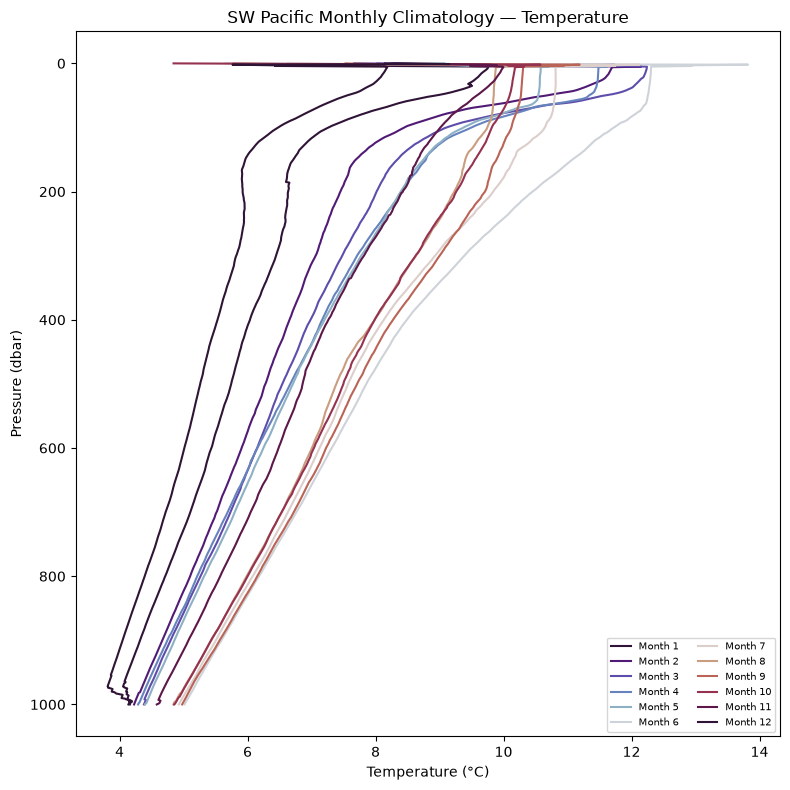

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.cm.twilight_shifted(np.linspace(0, 1, 12))

for m in range(1, 13):
    ax.plot(climatology_monthly["TEMP"].sel(month=m), climatology_monthly["pres"],
             color=cmap[m-1], label=f"Month {m}")

ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("SW Pacific Monthly Climatology — Temperature")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

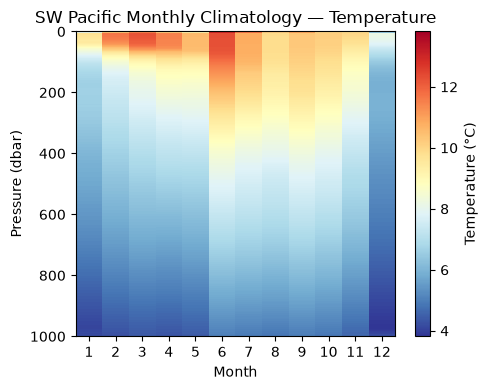

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.pcolormesh(
    climatology_monthly["month"], climatology_monthly["pres"],
    climatology_monthly["TEMP"].transpose("pres", "month"),
    cmap="RdYlBu_r", shading="auto"
)

ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("SW Pacific Monthly Climatology — Temperature")
ax.set_xticks(range(1, 13))
plt.colorbar(im, ax=ax, label="Temperature (°C)")
plt.tight_layout()
plt.show()

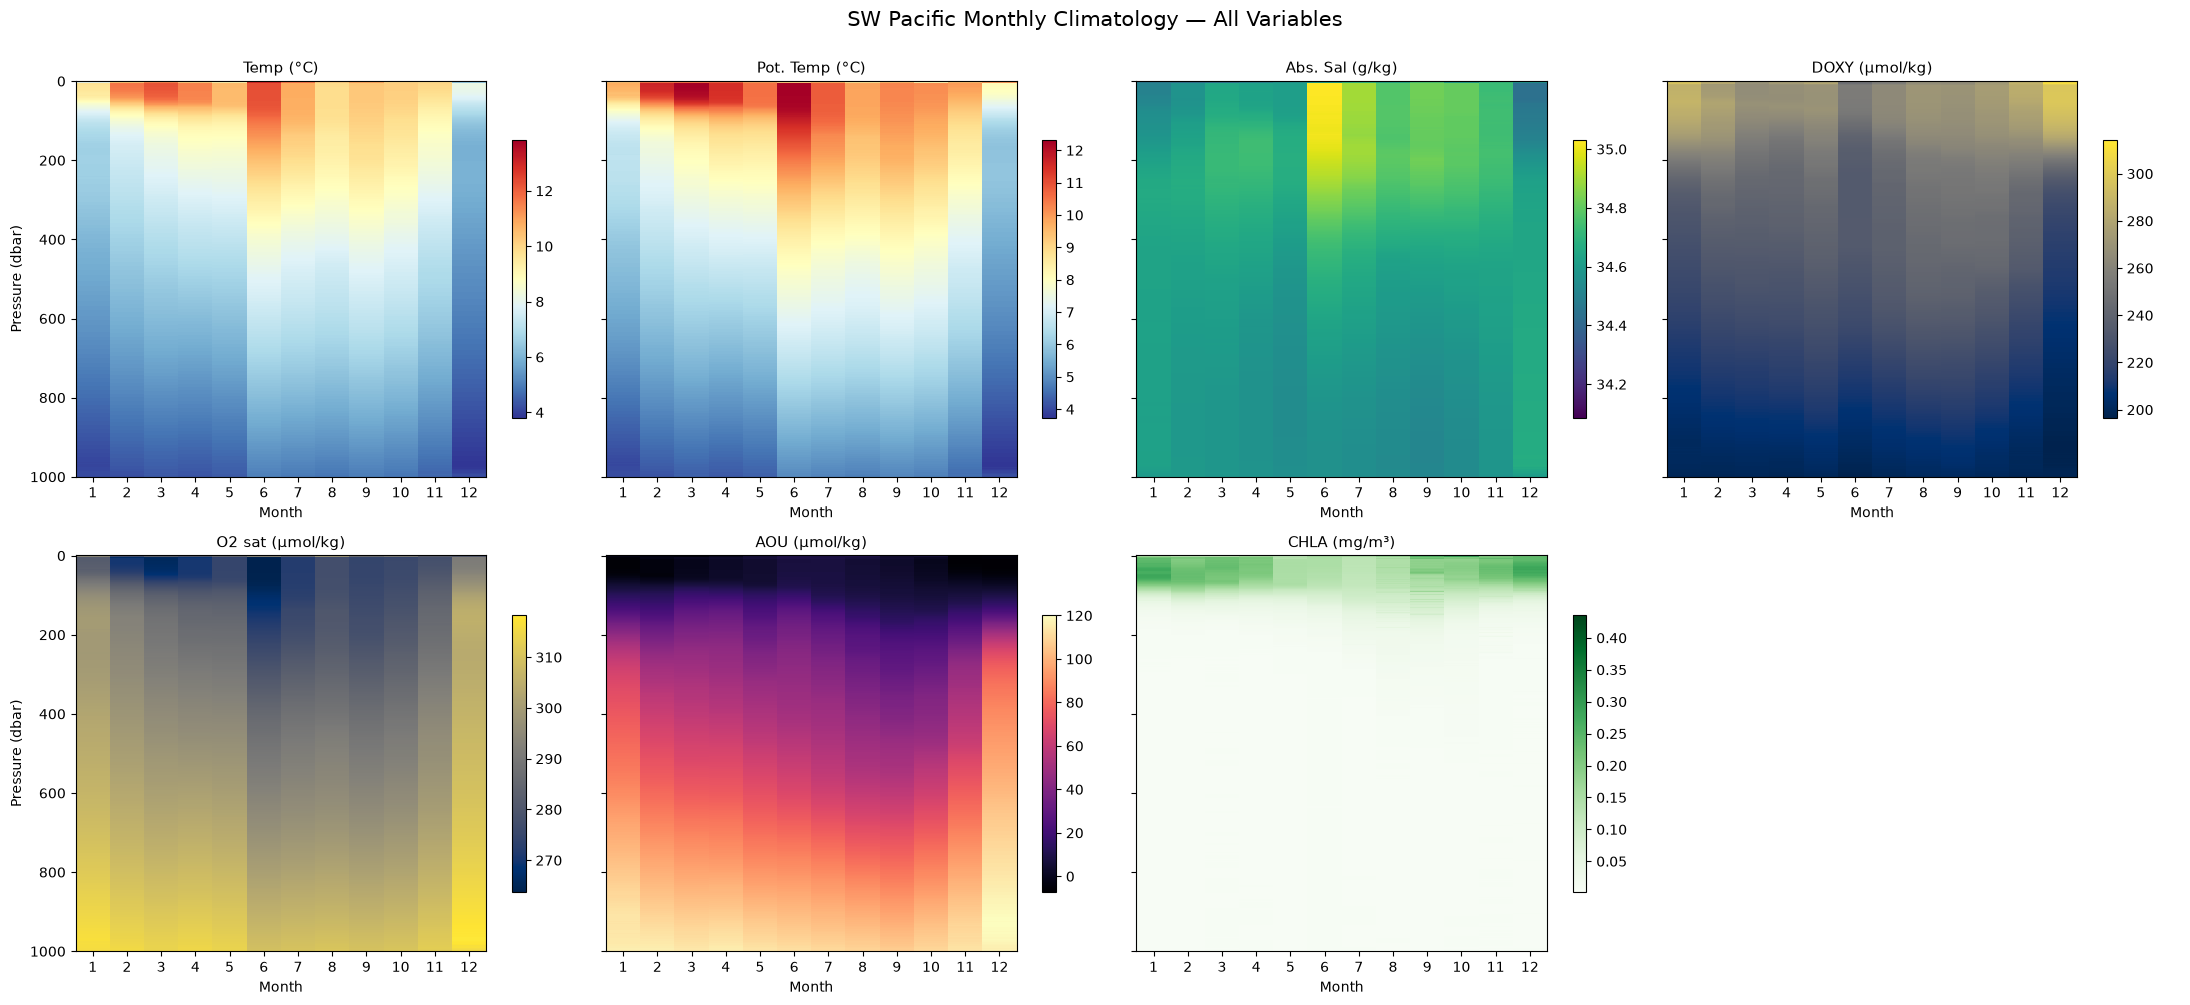

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

variables_to_plot = [
    ("TEMP", "Temp (°C)", "RdYlBu_r"),
    ("POTENTIAL_TEMP", "Pot. Temp (°C)", "RdYlBu_r"),
    ("ABS_SAL", "Abs. Sal (g/kg)", "viridis"),
    ("DOXY", "DOXY (µmol/kg)", "cividis"),
    ("O2_SATURATION", "O2 sat (µmol/kg)", "cividis"),
    ("AOU", "AOU (µmol/kg)", "magma"),
    ("CHLA", "CHLA (mg/m³)", "Greens"),
]

for ax, (var, label, cmap) in zip(axes, variables_to_plot):
    im = ax.pcolormesh(
        climatology_monthly["month"], climatology_monthly["pres"],
        climatology_monthly[var].transpose("pres", "month"),
        cmap=cmap, shading="auto"
    )
    ax.invert_yaxis()
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    plt.colorbar(im, ax=ax, shrink=0.7)

axes[0].set_ylabel("Pressure (dbar)")
axes[4].set_ylabel("Pressure (dbar)")

# Hide the unused 8th subplot
axes[7].axis("off")

fig.suptitle("SW Pacific Monthly Climatology — All Variables", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()